In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 从数据库拉取事件明细（带 event_time）
conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user='postgres',
    password='',
    port=5432
)

cur = conn.cursor()

query = """
SELECT 
    user_session,
    product_id,
    user_id,
    brand,
    event_time,
    event_type,
    group_type
FROM makeup_consumer_events."03_user_behavior_groups"
ORDER BY user_session, event_time
"""

cur.execute(query)
results = cur.fetchall()
columns = [desc[0] for desc in cur.description]
df = pd.DataFrame(results, columns=columns)

cur.close()
conn.close()

print(f"df shape: {df.shape}")
display(df.head())

df shape: (1154208, 7)


,user_session,product_id,user_id,brand,event_time,event_type,group_type
0,00002b0e-d7f7-454e-8386-431c4021a9f6,5875358,531784651,NaN,2019-12-18 06:48:39,['remove_from_cart'],C
1,00002b0e-d7f7-454e-8386-431c4021a9f6,5891029,531784651,irisk,2019-12-18 06:50:18,['cart'],B
2,00002b0e-d7f7-454e-8386-431c4021a9f6,5890841,531784651,irisk,2019-12-18 06:50:37,"['cart', 'remove_from_cart']",C
3,00002b0e-d7f7-454e-8386-431c4021a9f6,5622678,531784651,severina,2019-12-18 06:52:53,"['cart', 'remove_from_cart']",C
4,00002b0e-d7f7-454e-8386-431c4021a9f6,5622689,531784651,NaN,2019-12-18 06:54:17,"['cart', 'remove_from_cart']",C


In [4]:
# 提取小时
df['event_time'] = pd.to_datetime(df['event_time'])
df['hour'] = df['event_time'].dt.hour

# 处理 brand 缺失值
df['brand'] = df['brand'].fillna('Unknown Brand')
df['brand'] = df['brand'].replace('NaN', 'Unknown Brand')

print(f"缺失 brand 数: {df['brand'].isna().sum()}")
print(f"缺失 hour 数: {df['hour'].isna().sum()}")

缺失 brand 数: 0
缺失 hour 数: 0


In [5]:
# 创立新的df为target_df,使用isin
target_brands = ['runail', 'masura']
target_df = df[df['brand'].isin(target_brands)].copy()
print(f"target_df shape: {target_df.shape}")
display(target_df.head())

target_df shape: (140392, 8)


,user_session,product_id,user_id,brand,event_time,event_type,group_type,hour
7,00002b0e-d7f7-454e-8386-431c4021a9f6,5774352,531784651,runail,2019-12-18 07:07:33,['cart'],B,7
9,00002b0e-d7f7-454e-8386-431c4021a9f6,4905,531784651,runail,2019-12-18 07:09:04,['remove_from_cart'],C,7
10,00002b0e-d7f7-454e-8386-431c4021a9f6,5686278,531784651,masura,2019-12-18 07:10:56,['cart'],B,7
12,00002b0e-d7f7-454e-8386-431c4021a9f6,5877385,531784651,masura,2019-12-18 07:12:57,['cart'],B,7
16,00011b89-8220-4794-b653-f1eab289404d,5619863,591745098,runail,2019-12-24 11:52:26,"['cart', 'remove_from_cart']",C,11


In [6]:
# 按【品牌-小时-分组】统计各组操作次数
cross_pct = target_df.groupby(['brand', 'hour', 'group_type']).size().unstack(fill_value=0)
cross_pct['total'] = cross_pct.sum(axis=1)
display(cross_pct.head())


group_type     A    B    C  total
brand  hour                      
masura 0      72  341  141    554
       1      44  149  149    342
       2      59  175  148    382
       3      32  381  282    695
       4     131  479  475   1085

In [7]:
# 计算每个小时各品牌的【各组占比】（行品牌 × 小时，列 A/B/C）
cross_pct = cross_pct[['A', 'B', 'C']].div(cross_pct[['A', 'B', 'C']].sum(axis=1), axis=0) * 100
cross_pct = cross_pct.round(2)
cross_pct = cross_pct.reset_index()
print(cross_pct.head())

group_type   brand  hour      A      B      C
0           masura     0  13.00  61.55  25.45
1           masura     1  12.87  43.57  43.57
2           masura     2  15.45  45.81  38.74
3           masura     3   4.60  54.82  40.58
4           masura     4  12.07  44.15  43.78


In [8]:
# 计算 C组 相对于 A组 的【流失风险比】= C% / A%
# 比值 > 1 说明该品牌该时段 C组占比高于 A组，即流失风险高
cross_pct['C_vs_A'] = (cross_pct['C'] / cross_pct['A']).round(2)
display(cross_pct.head())
cross_pct.to_csv(r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\data\interim\05_brand_time_cross_analysis.csv', index=False)

group_type,brand,hour,A,B,C,C_vs_A
0,masura,0,13.00,61.55,25.45,1.96
1,masura,1,12.87,43.57,43.57,3.39
2,masura,2,15.45,45.81,38.74,2.51
3,masura,3,4.60,54.82,40.58,8.82
4,masura,4,12.07,44.15,43.78,3.63


In [9]:
def period_time(hour):
    if 8 <= hour < 12:
        return '购买高峰期'
    elif 18 <= hour < 22:
        return '流失高峰期'
    else:
        return '其他时段'
    
cross_pct['时间段'] = cross_pct['hour'].apply(period_time)
period_summary = cross_pct[cross_pct['时间段'] != '其他时段'].groupby(['时间段', 'brand'])[['A', 'B', 'C', 'C_vs_A']].mean().round(2).reset_index()
print(period_summary)
period_summary.to_csv(r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\data\interim\05_brand_time_period_summary.csv', index=False)

group_type    时间段   brand      A      B      C  C_vs_A
0           流失高峰期  masura  13.06  42.92  44.02    3.46
1           流失高峰期  runail  18.04  47.18  34.78    1.93
2           购买高峰期  masura  17.06  40.06  42.88    2.52
3           购买高峰期  runail  22.34  43.26  34.40    1.54


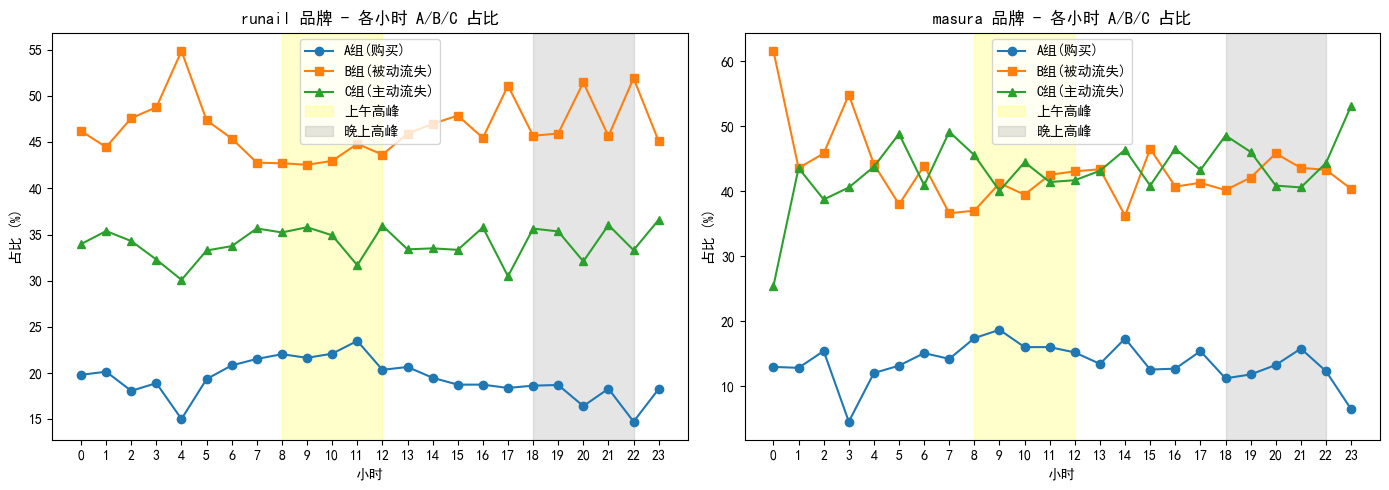

In [15]:
# 图1：两品牌各时段 A/B/C 占比对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, brand in enumerate(target_brands):
    brand_data = cross_pct[cross_pct['brand'] == brand]
    
    axes[i].plot(brand_data['hour'], brand_data['A'], label='A组(购买)', marker='o')
    axes[i].plot(brand_data['hour'], brand_data['B'], label='B组(被动流失)', marker='s')
    axes[i].plot(brand_data['hour'], brand_data['C'], label='C组(主动流失)', marker='^')
    
    axes[i].axvspan(8, 12, alpha=0.2, color='yellow', label='上午高峰')
    axes[i].axvspan(18, 22, alpha=0.2, color='gray', label='晚上高峰')
    
    axes[i].set_title(f'{brand} 品牌 - 各小时 A/B/C 占比')
    axes[i].set_xlabel('小时')
    axes[i].set_ylabel('占比 (%)')
    axes[i].legend()
    axes[i].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\05_brand_time_cross_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


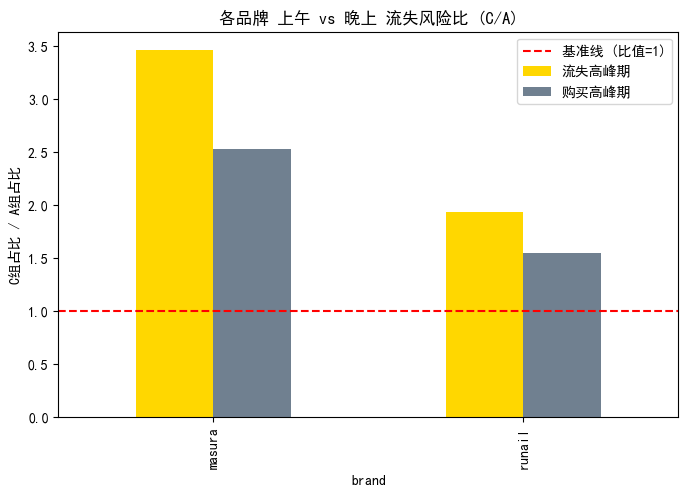

In [16]:
# 图2：上午 vs 晚上 两品牌 C_vs_A_ratio 对比
period_pivot = cross_pct[cross_pct['时间段'] != '其他时段'].pivot_table(
    index='brand',
    columns='时间段',
    values='C_vs_A'
)
period_pivot.plot(kind='bar', figsize=(8, 5), color=['#FFD700', '#708090'])
plt.title('各品牌 上午 vs 晚上 流失风险比 (C/A)')
plt.ylabel('C组占比 / A组占比')
plt.axhline(y=1, color='red', linestyle='--', label='基准线 (比值=1)')
plt.legend()
plt.savefig(r'C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\05_brand_period_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# 生成结论
runail_morning = period_pivot.loc['runail', '购买高峰期'] if '购买高峰期' in period_pivot.columns else None
runail_evening = period_pivot.loc['runail', '流失高峰期'] if '流失高峰期' in period_pivot.columns else None
masura_morning = period_pivot.loc['masura', '购买高峰期'] if '购买高峰期' in period_pivot.columns else None
masura_evening = period_pivot.loc['masura', '流失高峰期'] if '流失高峰期' in period_pivot.columns else None

print("=== 品牌 × 时间 交叉分析结论 ===")
print(f"\nrunail (购买代表):")
print(f"  上午 C/A 比值: {runail_morning}")
print(f"  晚上 C/A 比值: {runail_evening}")
print(f"\nmasura (流失代表):")
print(f"  上午 C/A 比值: {masura_morning}")
print(f"  晚上 C/A 比值: {masura_evening}")

if masura_morning and runail_morning and masura_evening and runail_evening:
    if masura_morning > masura_evening and runail_morning < runail_evening:
        print("\n结论：时间假设成立 —— 上午更倾向购买，晚上更倾向流失")
    elif masura_morning < masura_evening and runail_morning > runail_evening:
        print("\n结论：时间假设部分成立 —— 需要进一步分析")
    else:
        print("\n结论：时间假设不成立 —— 流失根源在品牌本身特征（价格、竞品策略等）")

=== 品牌 × 时间 交叉分析结论 ===

runail (购买代表):
  上午 C/A 比值: 1.545
  晚上 C/A 比值: 1.93

masura (流失代表):
  上午 C/A 比值: 2.525
  晚上 C/A 比值: 3.4625

结论：时间假设不成立 —— 流失根源在品牌本身特征（价格、竞品策略等）
